In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
datapath = r"D:\News Article Clustering Project\bbc"

In [3]:
data = []

for category in os.listdir(datapath):

    category_path = os.path.join(datapath, category)

    for filename in os.listdir(category_path):

        file_path = os.path.join(category_path, filename)

        with open(file_path, encoding='latin1') as file:
            text = file.read()

        data.append([text, category])

In [4]:
bbc = pd.DataFrame(data, columns=['text', 'category'])

In [5]:
bbc.shape

(2225, 2)

In [ ]:
bbc['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [17]:
bbc.isna().sum()

text        0
category    0
dtype: int64

In [8]:
bbc.duplicated().sum()

np.int64(0)

In [7]:
bbc = bbc.drop_duplicates()

In [26]:
bbc.to_csv('bbc.csv', index= False)

In [2]:
bbc = pd.read_csv('bbc.csv')

### Text Cleaning

In [3]:
import re

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

In [4]:
bbc['clean_text'] = bbc['text'].apply(clean_text)

In [30]:
bbc.head()

,text,category,clean_text
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,ad sale boost time warner profit quarterly pro...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,dollar gain greenspan speech dollar hit highes...
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,yukos unit buyer face loan claim owner embattl...
3,High fuel prices hit BA's profits\n\nBritish A...,business,high fuel price hit ba profit british airway b...
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,pernod takeover talk lift domecq share uk drin...


### TF-IDF Vectorization (converting words into numerics)

In [50]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(bbc['clean_text'])

In [20]:
X.shape

(2127, 5000)

In [51]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_reduced = svd.fit_transform(X)

In [52]:
X_reduced.shape

(2127, 100)

In [53]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

bbc['KMeans_Cluster'] = kmeans.fit_predict(X_reduced)

In [54]:
score = silhouette_score(
    X_reduced,
    bbc['KMeans_Cluster']
)

print(score)

0.037599810074539525


In [55]:
bbc['KMeans_Cluster'].value_counts(), bbc['category'].value_counts()

(KMeans_Cluster
 0    553
 1    515
 3    366
 2    353
 4    340
 Name: count, dtype: int64,
 category
 sport            505
 business         503
 politics         403
 entertainment    369
 tech             347
 Name: count, dtype: int64)

In [56]:
original_space_centroids = svd.inverse_transform(
    kmeans.cluster_centers_
)

terms = vectorizer.get_feature_names_out()

for i in range(5):
    top_terms = original_space_centroids[i].argsort()[-10:][::-1]

    print(f"\nCluster {i}")
    print([terms[ind] for ind in top_terms])


Cluster 0
['bn', 'company', 'firm', 'year', 'bank', 'market', 'sale', 'share', 'growth', 'economy']

Cluster 1
['game', 'england', 'player', 'win', 'match', 'club', 'cup', 'team', 'final', 'year']

Cluster 2
['mr', 'labour', 'election', 'party', 'blair', 'tory', 'government', 'would', 'minister', 'brown']

Cluster 3
['film', 'award', 'best', 'show', 'star', 'music', 'band', 'year', 'actor', 'oscar']

Cluster 4
['mobile', 'phone', 'technology', 'game', 'people', 'user', 'computer', 'service', 'net', 'software']


In [57]:
pd.crosstab(
    bbc['category'],
    bbc['KMeans_Cluster']
)

KMeans_Cluster,0,1,2,3,4
category,,,,,
business,489,1,4,2,7
entertainment,8,1,1,356,3
politics,48,3,347,1,4
sport,1,502,0,2,0
tech,7,8,1,5,326


## Agglomerative Clustering

In [97]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_reduced = svd.fit_transform(X)

agg = AgglomerativeClustering(
    n_clusters=5
)

bbc['Agg_Cluster'] = agg.fit_predict(X_reduced)

In [98]:
bbc['Agg_Cluster'].value_counts(), bbc['category'].value_counts()

(Agg_Cluster
 0    998
 1    509
 4    311
 2    194
 3    115
 Name: count, dtype: int64,
 category
 sport            505
 business         503
 politics         403
 entertainment    369
 tech             347
 Name: count, dtype: int64)

### PCA

In [63]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_reduced)

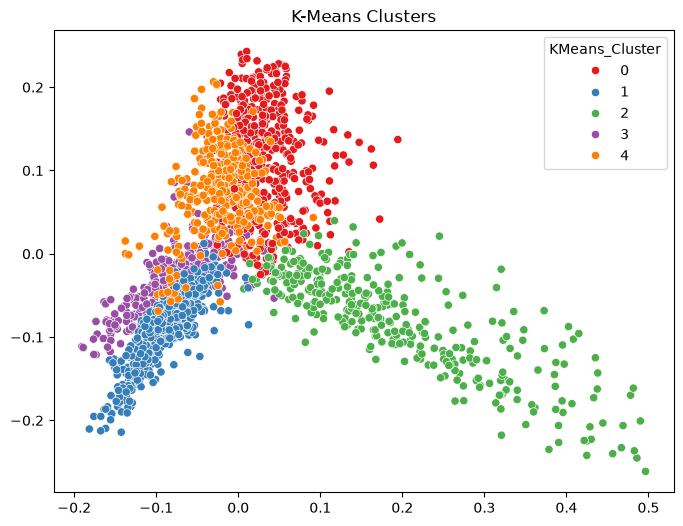

In [64]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=bbc['KMeans_Cluster'],
    palette='Set1'
)

plt.title("K-Means Clusters")
plt.show()

In [66]:
X_pca

array([[-0.02165673,  0.20475481],
       [ 0.04882553,  0.15302409],
       [ 0.03376717,  0.13677956],
       ...,
       [ 0.03838772,  0.05686918],
       [ 0.03428341,  0.05703156],
       [-0.09765891, -0.06882963]], shape=(2127, 2))